<a href="https://colab.research.google.com/github/Kei-exee/GUIA-IA/blob/main/guia_6691_22_4724.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving FuelConsumption.csv to FuelConsumption (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
# Sumarizar los datos
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [ ]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

#Seleccionemos algunas características para explorar más en detalle.

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


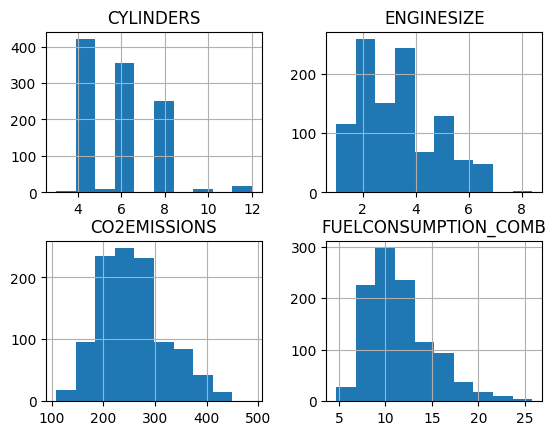

In [ ]:
#podemos dibujar cada una de estas características:

viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()


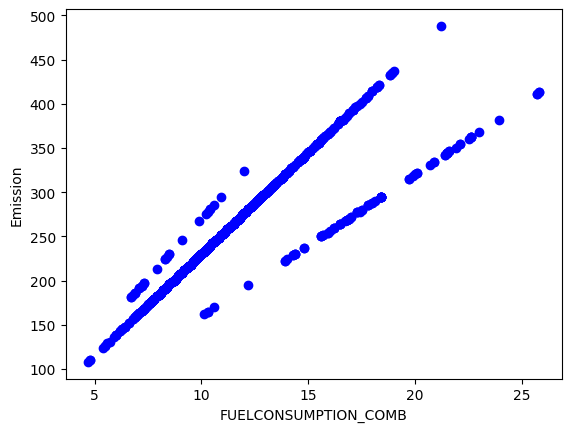

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

#comparemos estas características anteriores con la emisión de carbono, para ver cuán lineal es la regresión:

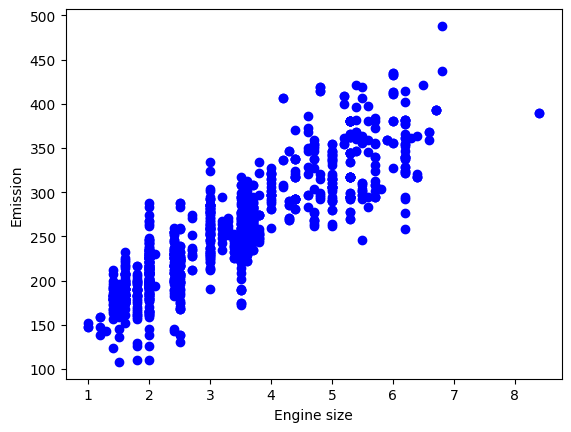

In [ ]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

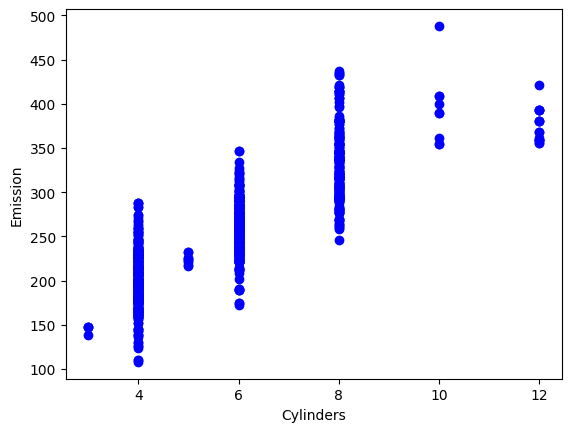

In [ ]:
#Dibuja CYLINDER vs la Emisión, para ver cuán lineal es su relación:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()


In [ ]:
#Creando el set de datos de entrenamiento y de prueba
#Train/Test Split divide el dataseet en un set de training y otro de testing, siendo excluyentes. Después de ello, entrenamos con el set de training y pruebas con el de testing.
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

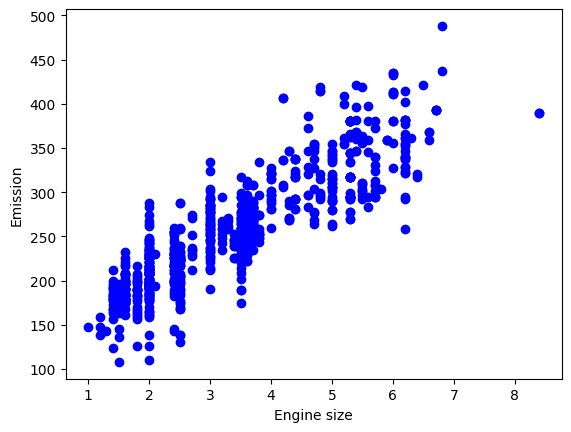

In [ ]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [ ]:
#coeficientes
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)
print ('coeficientes: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

coeficientes:  [[38.94390447]]
Intercept:  [126.04429298]


Text(0.5, 0, 'Engine size')

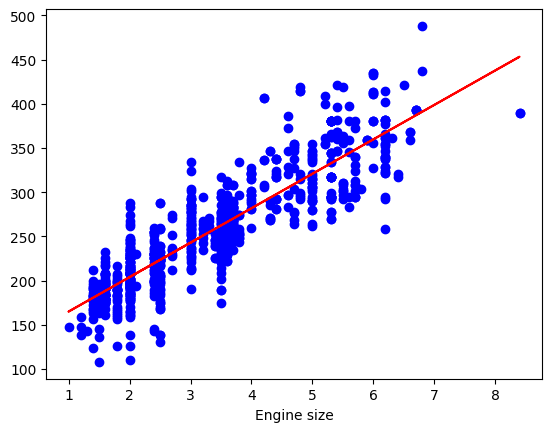

In [ ]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Error medio absoluto: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Suma residual de los cuadrados (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Error medio absoluto: 23.72
Suma residual de los cuadrados (MSE): 1000.07
R2-score: 0.64


Analisis de precision del modelo
el coeficiente 38.9... incica que por cada unidad adicional en el tamaño del motor, las emisiones de CO2 aumentan aprox. 38.94g/mk, esto muestra una relacion positiva entre ambas variables a mayor tamaño del motor mayores emisiones

Retos

In [ ]:
#Utilice el algoritmo K-fold cross
#validacion e indique el polinomio
#que tenga mejor precisión.

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = cdf[['ENGINESIZE']]
y = cdf['CO2EMISSIONS']

modelo = LinearRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(modelo, X, y, cv=kfold, scoring='r2')

print("Resultados R2 de cada una de las pruebas:", scores)
print("Promedio R2:", scores.mean())

Resultados R2 de cada una de las pruebas: [0.76448092 0.78619301 0.7571463  0.77533842 0.71045454]
Promedio R2: 0.7587226382140251


In [ ]:
#Analice las variables e implemente un modelo de
#regresión múltiple que mejore la predicción del modelo.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)
predicciones = modelo_multi.predict(X_test)

print("coeficientes:", modelo_multi.coef_)
print("intercepto:", modelo_multi.intercept_)
print("R2:", r2_score(y_test, predicciones))

coeficientes: [11.2094395   7.15561381  9.5208118 ]
intercepto: 67.3483851836209
R2: 0.875970520691407


In [ ]:
#Cuales son las variables poco significativas
#en el diseño del modelo?
print(modelo_multi.coef_)

[11.2094395   7.15561381  9.5208118 ]
